Problem Definition & Data Understanding- Clearly define the modeling problem
Demonstrate strong understanding of the dataset
Use exploratory data analysis (EDA) to inform modeling decisions
Data Preparation & Feature Engineering
Perform appropriate data cleaning and preprocessing
Apply meaningful feature engineering and feature selection
Clearly explain and justify feature choices
Demonstrate how feature decisions impact model performance

In [ ]:
import pandas as pd
import numpy as np

# =========================
# importing visualization libraries
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

# =========================
# importing libraries for modeling and preprocessing
# =========================
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy.stats import chi2_contingency

# =========================
# import libraries for models
# =========================
from sklearn.linear_model import LogisticRegression

# =========================
# importing libraries for metric evaluation
# =========================
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer
)

In [68]:
# importing the data
survey = pd.read_csv("../data/survey.csv")
df = survey.copy()
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [69]:
print(df.columns.tolist())
print("Shape", df.shape)

['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']
Shape (1259, 27)


In [70]:
# dropping columns
df = df.drop(columns=["Timestamp", "comments"], errors="ignore")

# converting to binary numbers
df["treatment"] = (df["treatment"].astype(str).str.strip().str.lower().map({"no": 0, "yes": 1}))

,column,missing_rate,missing_percent
0,state,0.409055,40.905481
1,work_interfere,0.209690,20.969023
2,self_employed,0.014297,1.429706
3,Age,0.000000,0.000000
4,Country,0.000000,0.000000
5,Gender,0.000000,0.000000
6,family_history,0.000000,0.000000
7,treatment,0.000000,0.000000
8,no_employees,0.000000,0.000000
9,remote_work,0.000000,0.000000


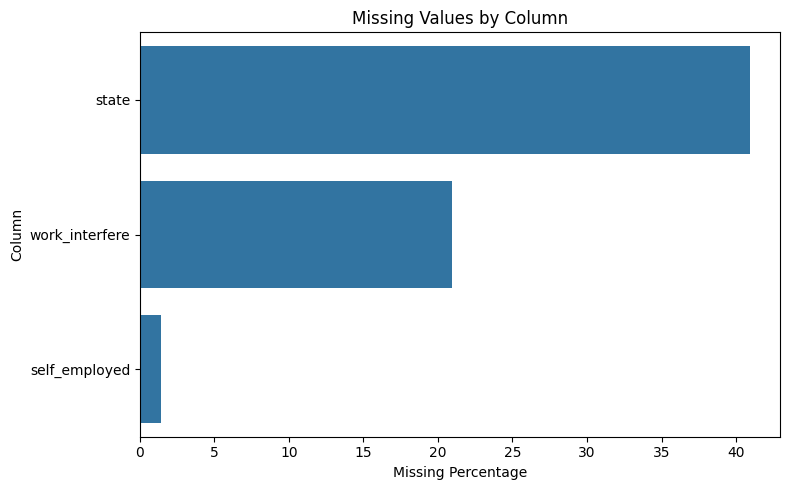

In [71]:
# Missingness summary before cleaning
missing_summary = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_rate"]
missing_summary["missing_percent"] = missing_summary["missing_rate"] * 100

display(missing_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=missing_summary[missing_summary["missing_percent"] > 0],
    x="missing_percent",
    y="column"
)
plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [72]:
# Clean Age and Gender before EDA/modeling

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Remove implausible working-age values
df = df[(df["Age"] >= 18) & (df["Age"] <= 80)].copy()

# Save original gender for before/after comparison
df["Gender_original"] = df["Gender"]

df["Gender_cleaned"] = (
    df["Gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)

male_terms = [
    "male", "m", "man", "cis male", "male-ish", "maile", "mal",
    "male (cis)", "make", "msle", "mail", "malr", "cis man"
]

female_terms = [
    "female", "f", "woman", "cis female", "femake", "female (cis)",
    "cis-female/femme", "female (trans)"
]

df["Gender_cleaned"] = np.where(
    df["Gender_cleaned"].isin(male_terms), "Male",
    np.where(df["Gender_cleaned"].isin(female_terms), "Female", "Other")
)

# Drop original free-text gender after creating cleaned version
df = df.drop(columns=["Gender"])

In [73]:
# Column-specific missing value handling

# comments and Timestamp were already dropped
df = df.drop(columns=["Timestamp", "comments"], errors="ignore")

# Treatment to binary
# Robust treatment conversion
# Handles both original Yes/No values and already-converted 0/1 values

if df["treatment"].dtype == "object" or df["treatment"].dtype == "string":
    df["treatment"] = (
        df["treatment"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"no": 0, "yes": 1})
    )
else:
    df["treatment"] = df["treatment"].astype(int)

print(df["treatment"].value_counts(dropna=False))

# work_interfere is important, so preserve missingness as Unknown
df["work_interfere"] = df["work_interfere"].fillna("Unknown")

# self_employed has low missingness, so impute mode
df["self_employed"] = df["self_employed"].fillna(df["self_employed"].mode()[0])

# state is structurally missing for many non-US respondents
df["state_missing"] = df["state"].isna().astype(int)
df["state"] = df["state"].fillna("Unknown_or_Non_US")

# Optional country simplification
df["us_based"] = (df["Country"] == "United States").astype(int)

print("Remaining missing values:")
display(df.isna().sum().sort_values(ascending=False).head(10))

treatment
1    632
0    619
Name: count, dtype: int64
Remaining missing values:


Age               0
Country           0
state             0
self_employed     0
family_history    0
treatment         0
work_interfere    0
no_employees      0
remote_work       0
tech_company      0
dtype: int64

# Exploratory Data Analysis

Original Gender values:


Gender_original
Male                     612
male                     204
Female                   121
M                        116
female                    62
F                         38
m                         34
f                         15
Make                       4
Woman                      3
Male                       3
Cis Male                   2
Female                     2
Man                        2
Female (trans)             2
Male-ish                   1
maile                      1
Trans-female               1
Cis Female                 1
something kinda male?      1
Name: count, dtype: int64

Cleaned Gender values:


Gender_cleaned
Male      986
Female    248
Other      17
Name: count, dtype: int64

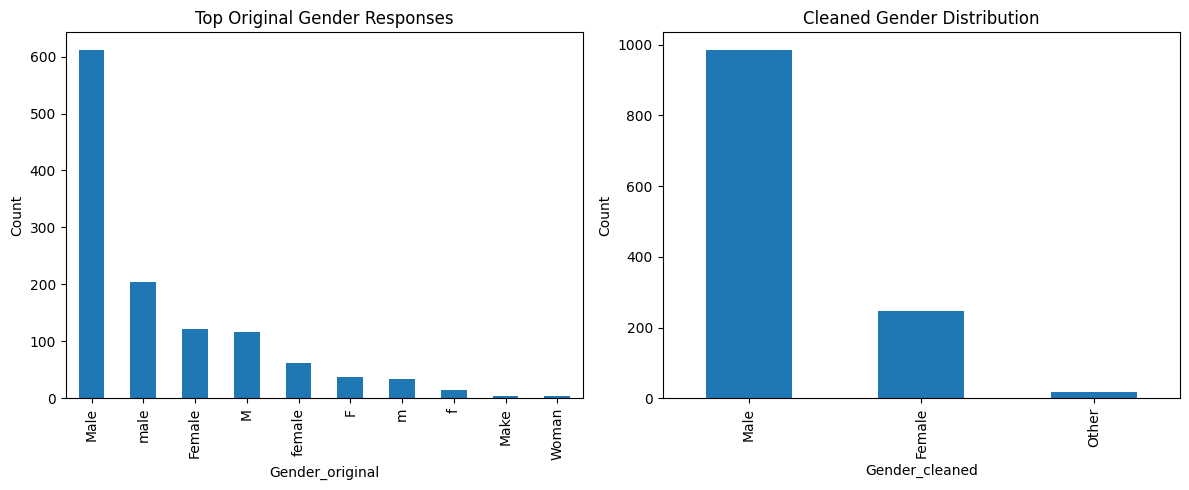

In [74]:
# Gender distribution before and after cleaning

print("Original Gender values:")
display(df["Gender_original"].value_counts().head(20))

print("Cleaned Gender values:")
display(df["Gender_cleaned"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["Gender_original"].value_counts().head(10).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top Original Gender Responses")
axes[0].set_ylabel("Count")

df["Gender_cleaned"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Cleaned Gender Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

C:\Users\ivpri\AppData\Local\Temp\ipykernel_20636\282227908.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_for_cramers = df.select_dtypes(include=["object"]).columns.tolist()


,feature,cramers_v_with_treatment
4,work_interfere,0.685344
3,family_history,0.375035
9,care_options,0.272528
22,Gender_original,0.263795
0,Country,0.233254
1,state,0.225844
8,benefits,0.225648
23,Gender_cleaned,0.196143
13,leave,0.151939
21,obs_consequence,0.150252


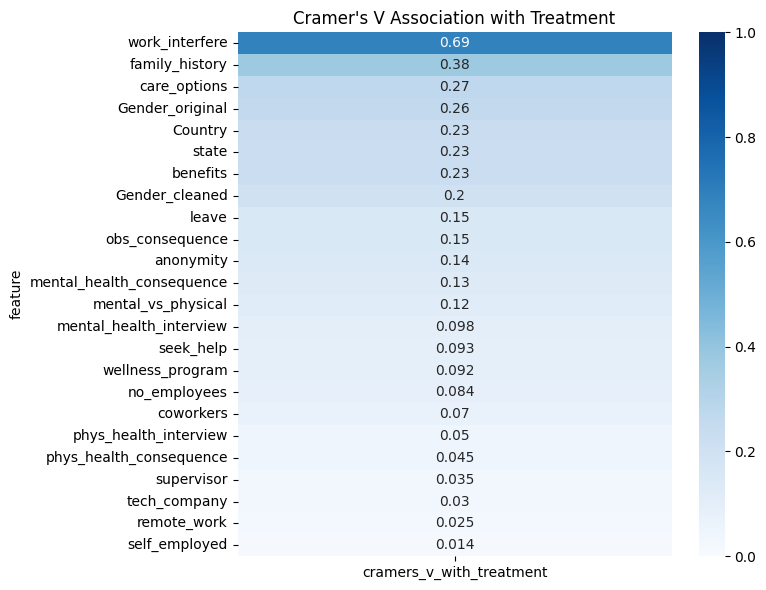

In [75]:
# Cramer's V association with treatment

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    
    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    
    return np.sqrt((chi2 / n) / min(k - 1, r - 1))

cat_cols_for_cramers = df.select_dtypes(include=["object"]).columns.tolist()

cramers_results = []

for col in cat_cols_for_cramers:
    cramers_results.append({
        "feature": col,
        "cramers_v_with_treatment": cramers_v(df[col], df["treatment"])
    })

cramers_df = (
    pd.DataFrame(cramers_results)
    .dropna()
    .sort_values("cramers_v_with_treatment", ascending=False)
)

display(cramers_df)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cramers_df.set_index("feature")[["cramers_v_with_treatment"]],
    annot=True,
    cmap="Blues",
    vmin=0,
    vmax=1
)
plt.title("Cramer's V Association with Treatment")
plt.tight_layout()
plt.show()

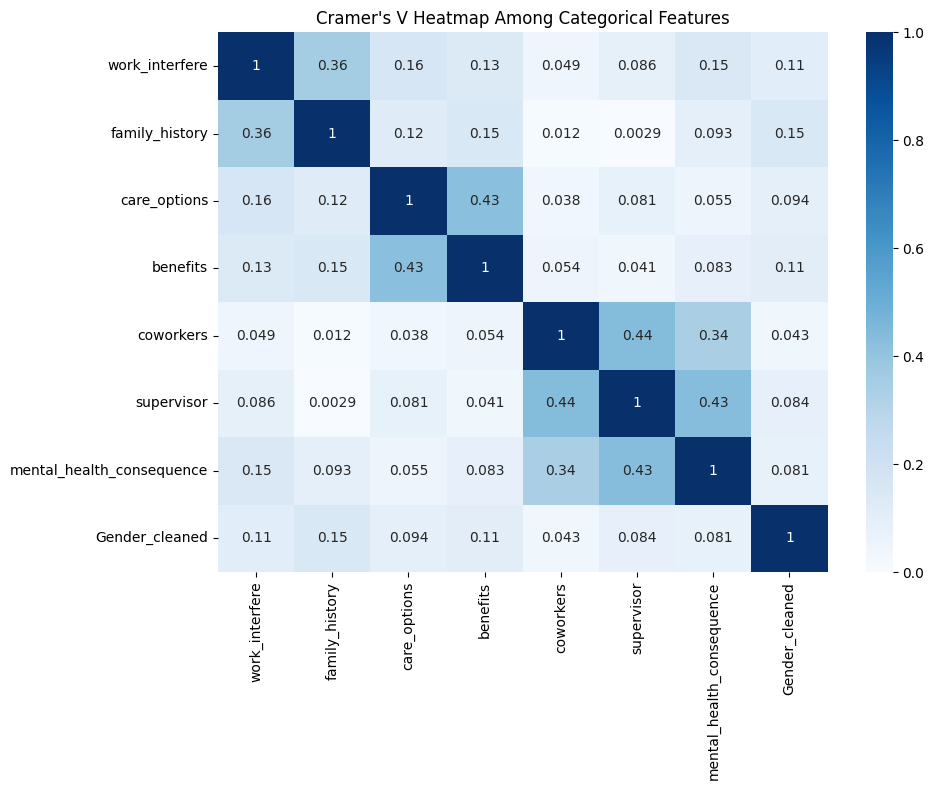

In [76]:
# Cramer's V heatmap among selected categorical predictors

selected_cat_cols = [
    "work_interfere",
    "family_history",
    "care_options",
    "benefits",
    "coworkers",
    "supervisor",
    "mental_health_consequence",
    "Gender_cleaned"
]

selected_cat_cols = [col for col in selected_cat_cols if col in df.columns]

cramers_matrix = pd.DataFrame(
    index=selected_cat_cols,
    columns=selected_cat_cols,
    dtype=float
)

for col1 in selected_cat_cols:
    for col2 in selected_cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="Blues",
    vmin=0,
    vmax=1
)
plt.title("Cramer's V Heatmap Among Categorical Features")
plt.tight_layout()
plt.show()

In [77]:
# checking for class imbalance
df['treatment'].value_counts(normalize=True)

treatment
1    0.505196
0    0.494804
Name: proportion, dtype: float64

In [78]:
# understanding categorical data

# Rebuild cat_cols from the current df so it does not include dropped columns like Gender
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

# Do not include helper/original columns in this summary
cat_cols = [col for col in cat_cols if col not in ["Gender_original"]]

cat_summary = []

for col in cat_cols:
    grouped = df.groupby(col)["treatment"].agg(["count", "mean"])

    max_rate = grouped["mean"].max()
    min_rate = grouped["mean"].min()
    spread = max_rate - min_rate
    min_count = grouped["count"].min()

    cat_summary.append({
        "feature": col,
        "max_treatment_rate": max_rate,
        "min_treatment_rate": min_rate,
        "difference_between_max_and_min": spread,
        "minimum_group_size": min_count,
        "number_of_unique_responses": df[col].nunique()
    })

cat_summary_df = pd.DataFrame(cat_summary)

cat_summary_df = cat_summary_df.sort_values(
    by="difference_between_max_and_min",
    ascending=False
)

print("\nCategorical Feature Summary:")
display(cat_summary_df)


Categorical Feature Summary:


,feature,max_treatment_rate,min_treatment_rate,difference_between_max_and_min,minimum_group_size,number_of_unique_responses
0,Country,1.000000,0.000000,1.000000,1,46
1,state,1.000000,0.000000,1.000000,1,46
4,work_interfere,0.850000,0.015267,0.834733,140,5
3,family_history,0.740286,0.354331,0.385956,489,2
9,care_options,0.690205,0.392971,0.297234,313,3
8,benefits,0.638478,0.371007,0.267470,371,3
22,Gender_cleaned,0.705882,0.454361,0.251521,17,3
13,leave,0.680412,0.450980,0.229432,97,5
21,obs_consequence,0.690608,0.473832,0.216776,181,2
18,mental_health_interview,0.560976,0.396135,0.164840,41,3


In [79]:
top_feature = cat_summary_df.iloc[0]["feature"]

top_cat_cols = (
    cat_summary_df[
        (cat_summary_df["difference_between_max_and_min"] >= 0.10) &
        (cat_summary_df["minimum_group_size"] >= 50)
    ]["feature"]
    .tolist()
)

print("Categorical features with higher association with treatment:", top_cat_cols)

Categorical features with higher association with treatment: ['work_interfere', 'family_history', 'care_options', 'benefits', 'leave', 'obs_consequence', 'mental_health_consequence', 'wellness_program', 'anonymity', 'mental_vs_physical', 'seek_help', 'no_employees', 'coworkers']


In [80]:
# I noticed that there are both countries and state columns so I wanted to see the distribution within the dataset of countries
country_age_summary = (
    df.groupby("Country")["Age"]
    .agg(["count", "min", "max", "mean", "median"])
    .sort_values(by="count", ascending=False)
)

country_age_summary

,count,min,max,mean,median
Country,,,,,
United States,746,18,72,33.130027,32.0
United Kingdom,184,18,55,30.940217,31.0
Canada,72,19,43,29.319444,29.0
Germany,45,21,43,30.422222,30.0
Ireland,27,23,45,31.925926,32.0
Netherlands,27,18,42,31.888889,33.0
Australia,21,20,48,29.000000,27.0
France,13,24,50,31.538462,28.0
India,10,20,31,24.500000,23.0


In [81]:
# Country has many sparse categories, so I use the us_based indicator created earlier
# and drop the original Country column before modeling.

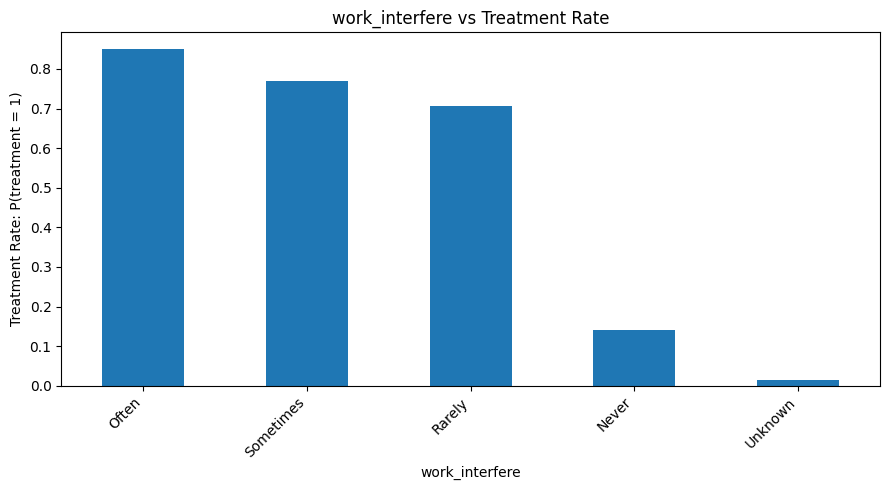

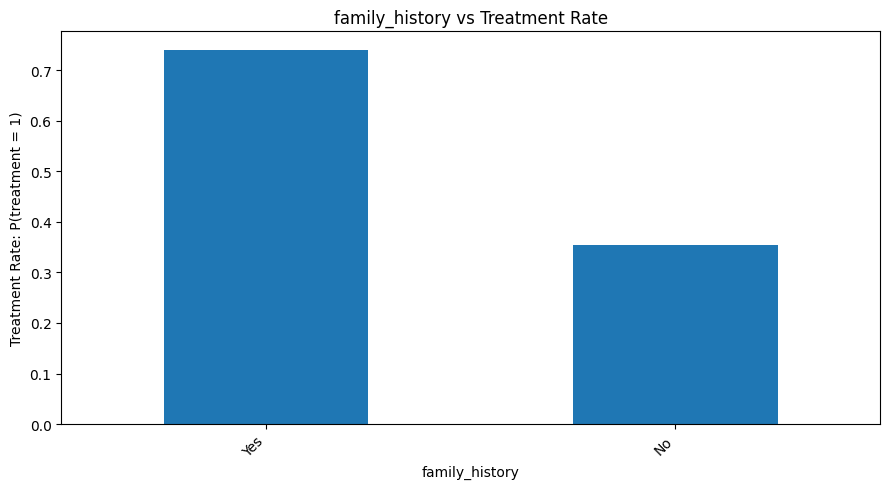

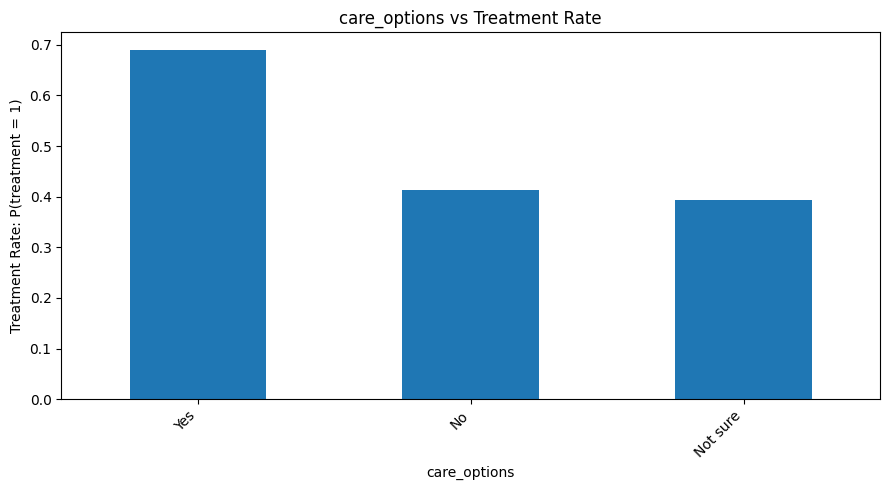

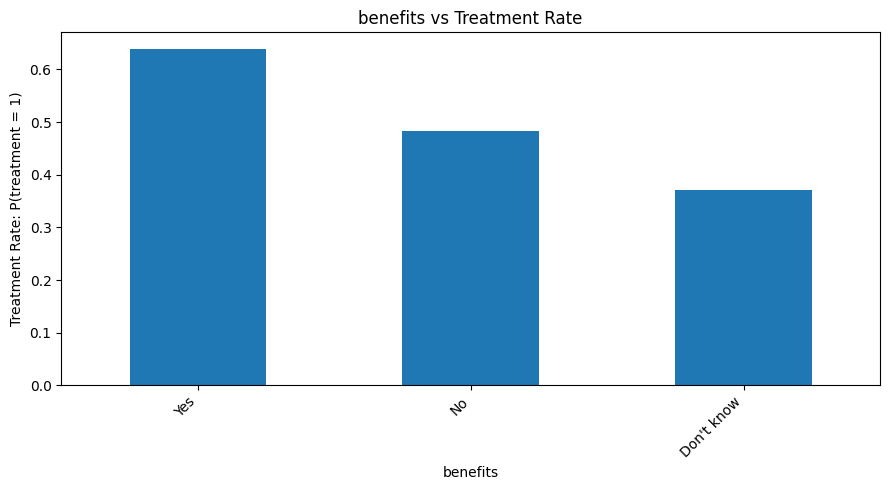

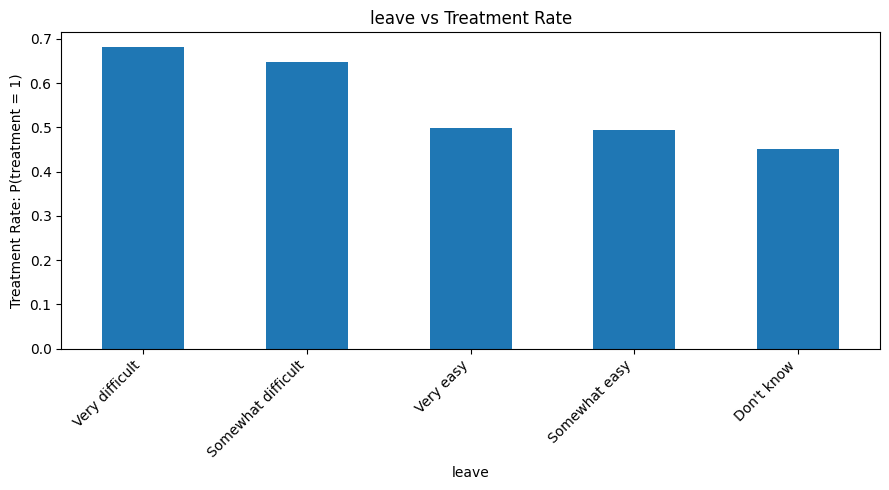

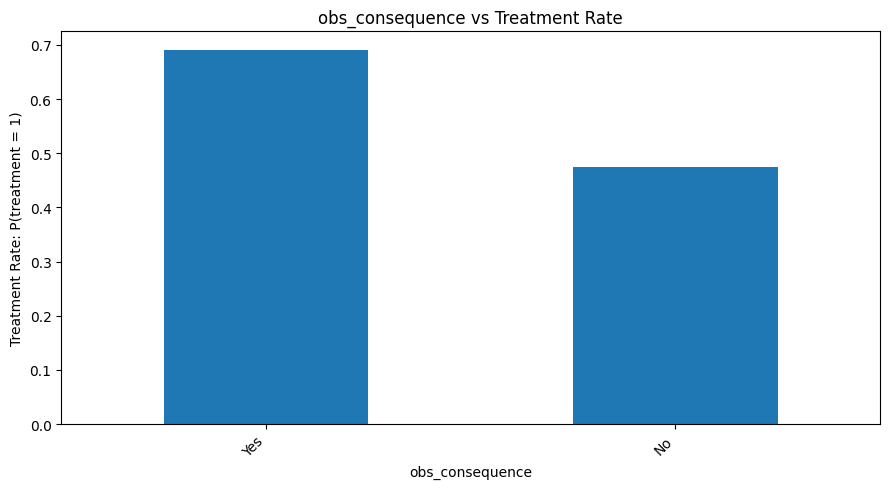

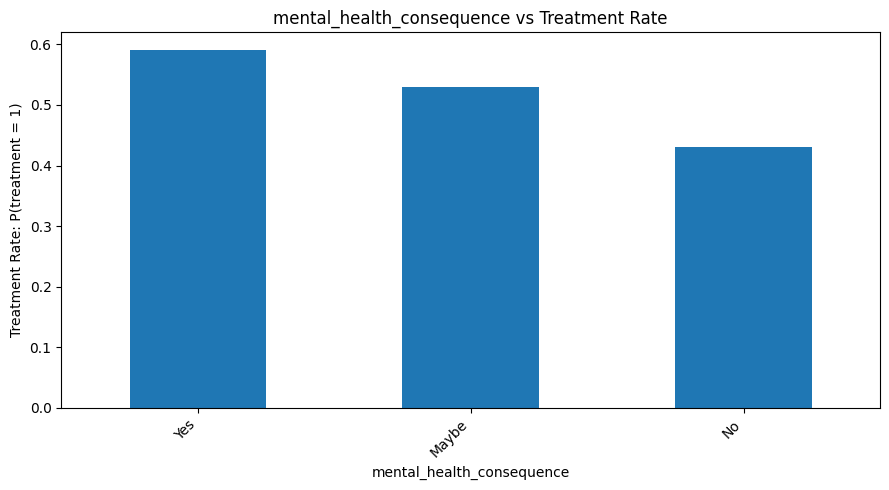

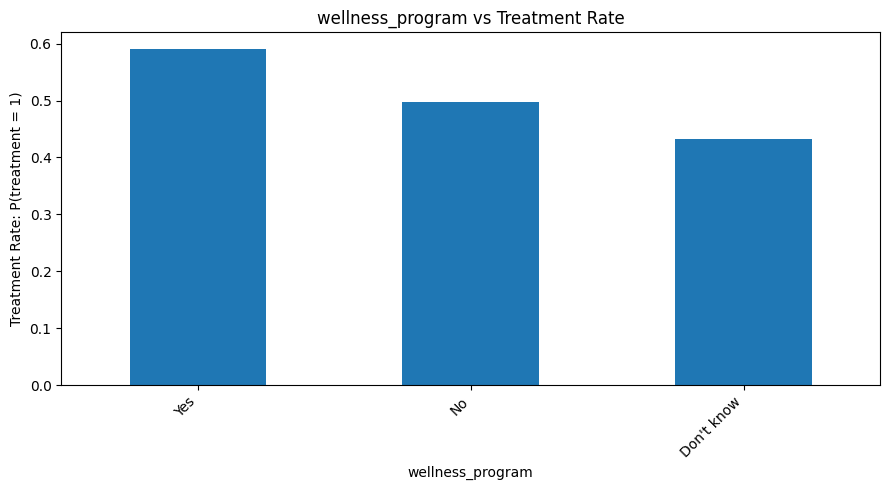

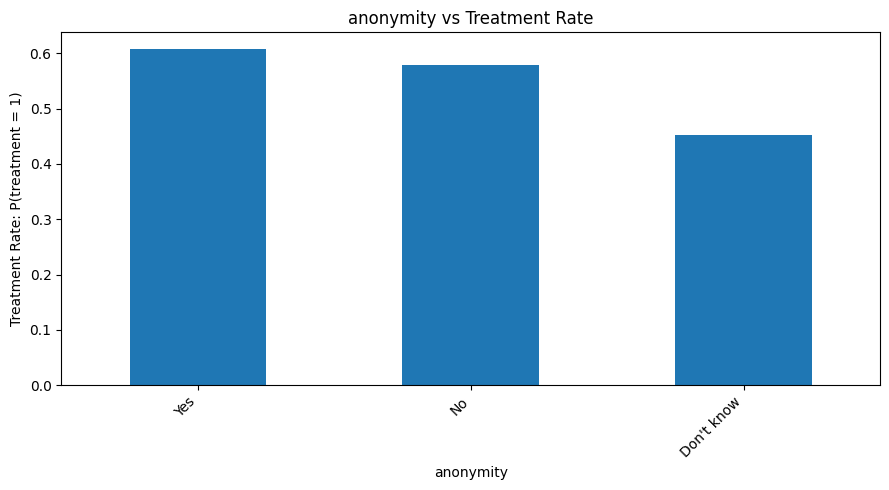

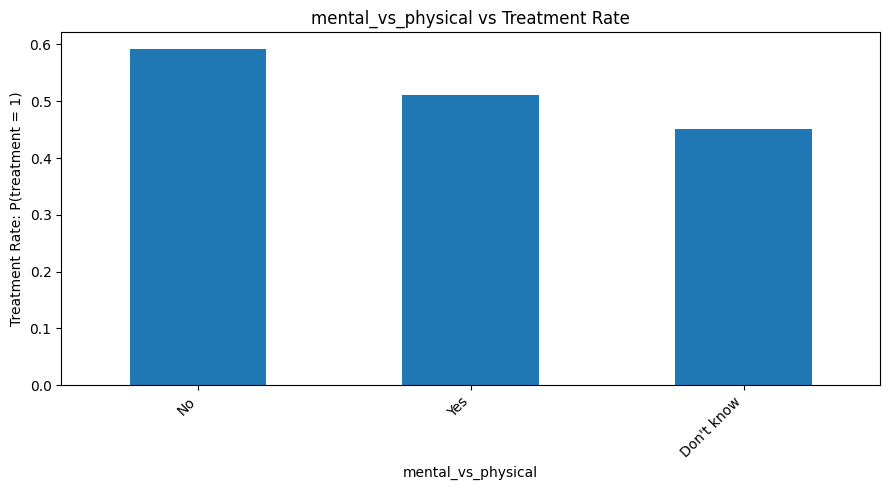

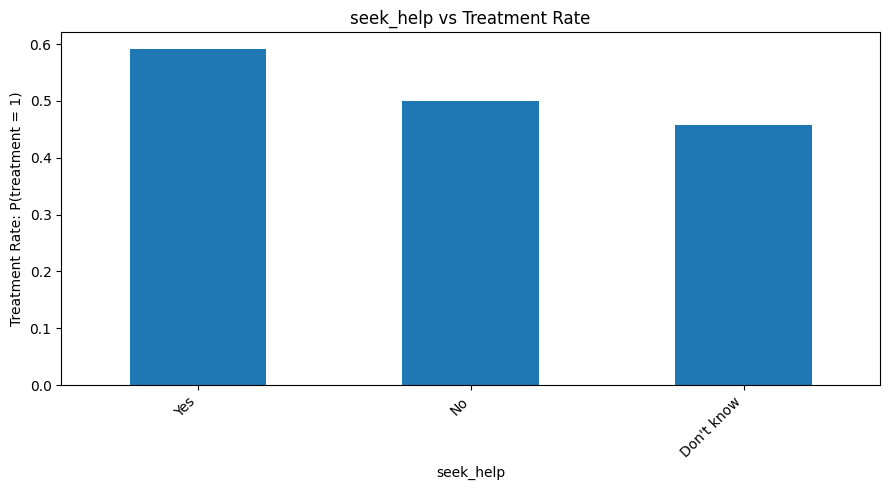

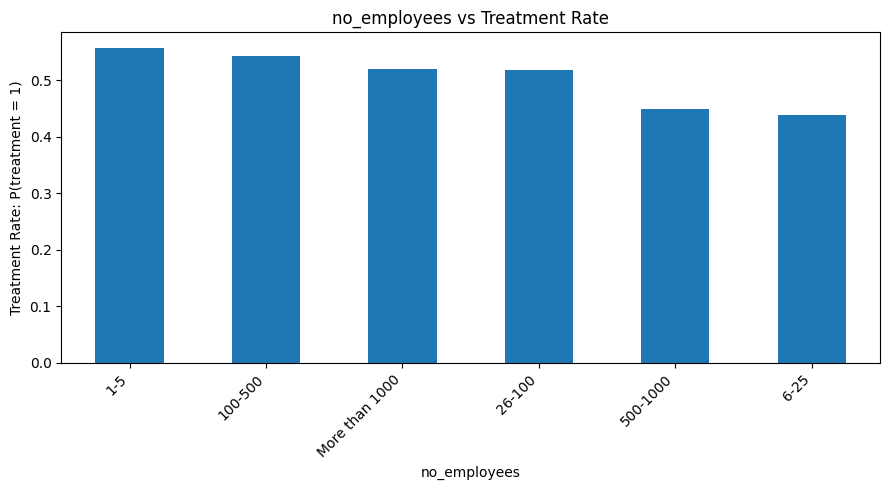

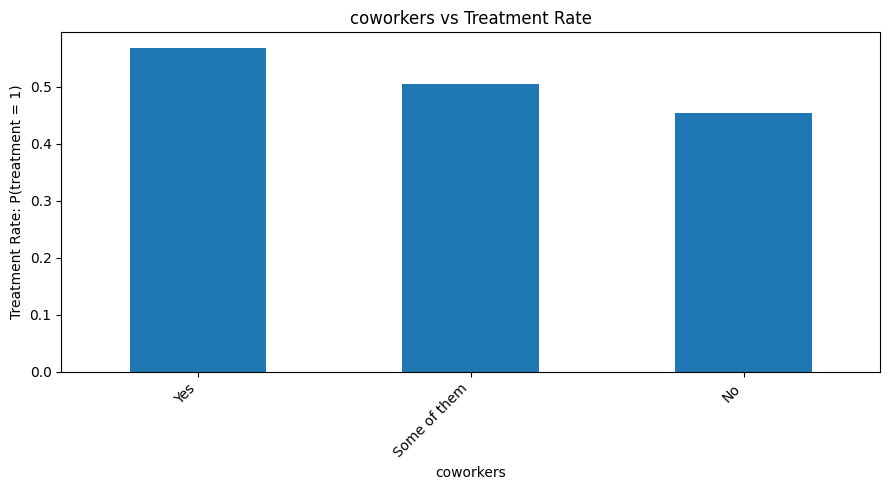

In [82]:
# plotting the top categorical columns
for col in top_cat_cols:

    rate = (
        df
        .groupby(col)["treatment"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 5))

    rate.plot(kind="bar")

    plt.title(f"{col} vs Treatment Rate")

    plt.ylabel("Treatment Rate: P(treatment = 1)")
    plt.xlabel(col)

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [83]:
num_summary = []

for col in num_cols:

    grouped = (
        df
        .groupby("treatment")[col]
        .agg(["mean", "median", "count"])
    )

    # ensure both treatment groups exist
    if 0 in grouped.index and 1 in grouped.index:

        mean_diff = abs(
            grouped.loc[1, "mean"] - grouped.loc[0, "mean"]
        )

        median_diff = abs(
            grouped.loc[1, "median"] - grouped.loc[0, "median"]
        )

        num_summary.append({
            "feature": col,
            "mean_difference": mean_diff,
            "median_difference": median_diff,
            "mean_no_treatment": grouped.loc[0, "mean"],
            "mean_treatment": grouped.loc[1, "mean"],
            "sample_size_no_treatment": grouped.loc[0, "count"],
            "sample_size_treatment": grouped.loc[1, "count"]
        })

num_summary_df = pd.DataFrame(num_summary)

num_summary_df.sort_values(
    by="median_difference",
    ascending=False
)

,feature,mean_difference,median_difference,mean_no_treatment,mean_treatment,sample_size_no_treatment,sample_size_treatment
0,Age,1.072861,1.0,31.534733,32.607595,619,632


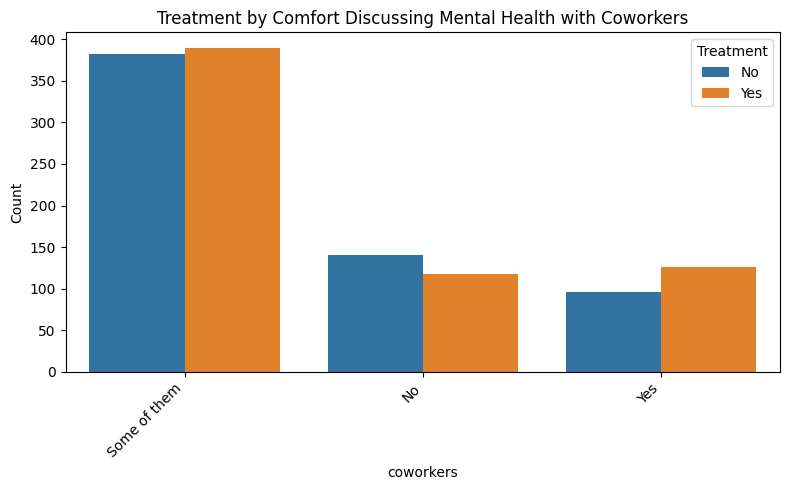

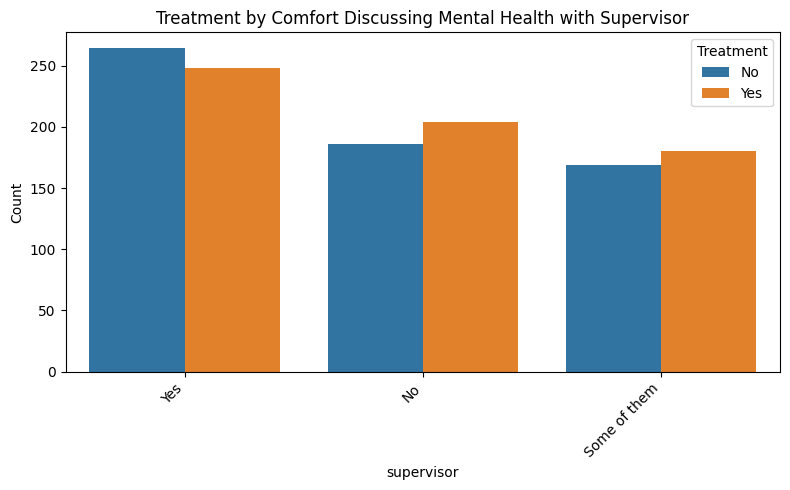

In [84]:
# Count plot of treatment by coworkers and supervisor
comfort_cols = ["coworkers", "supervisor"]

for col in comfort_cols:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=col,
        hue="treatment"
    )

    plt.title(f"Treatment by Comfort Discussing Mental Health with {col.title()}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Treatment", labels=["No", "Yes"])

    plt.tight_layout()
    plt.show()

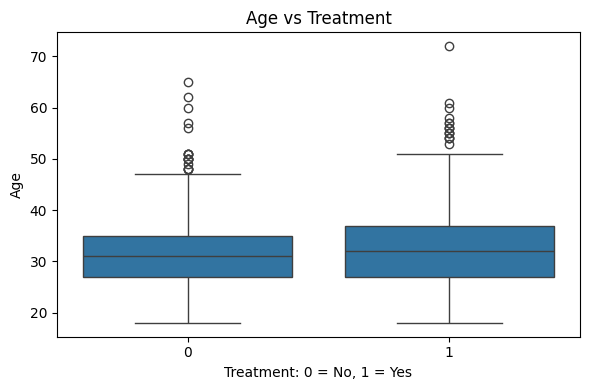

In [85]:
top_num_cols = ["Age"]

for col in top_num_cols:
    plt.figure(figsize=(6, 4))

    sns.boxplot(
        x="treatment",
        y=col,
        data=df
    )

    plt.title(f"{col} vs Treatment")
    plt.xlabel("Treatment: 0 = No, 1 = Yes")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

After filtering implausible age values, the age distribution is more reasonable for modeling.

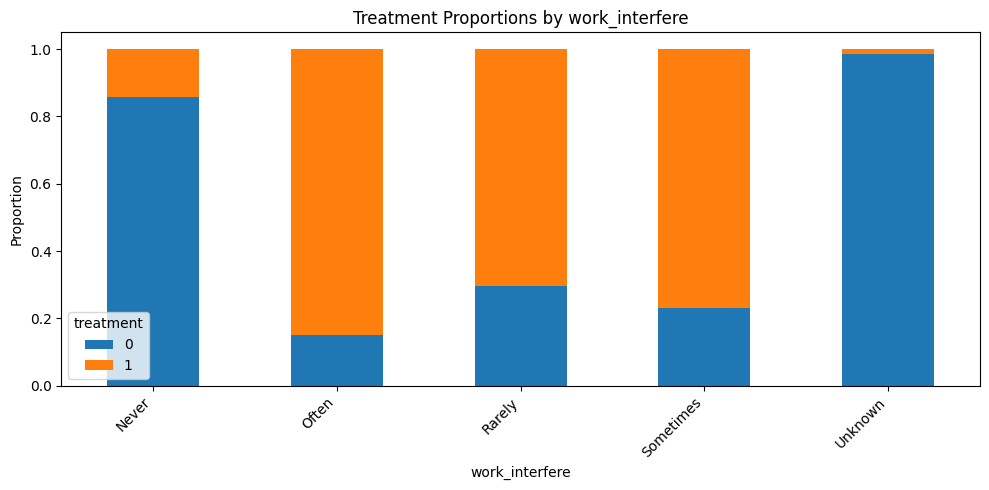

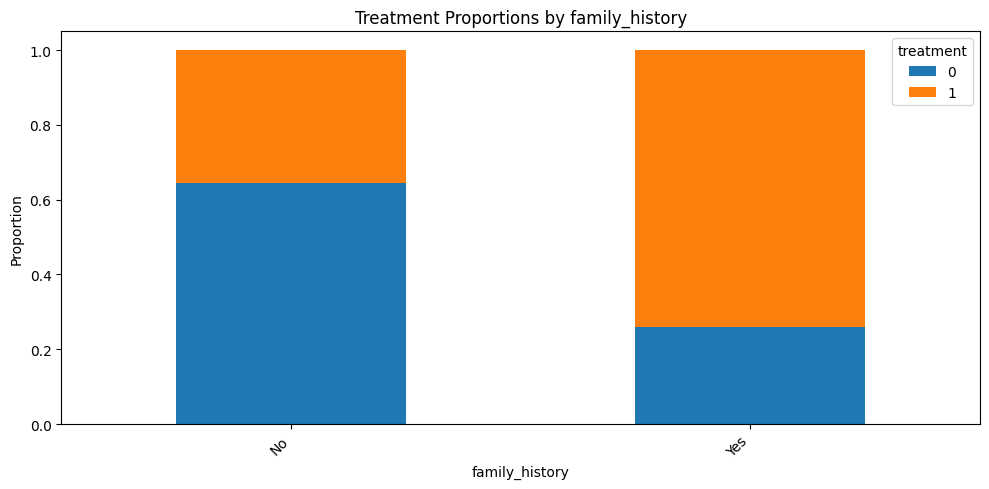

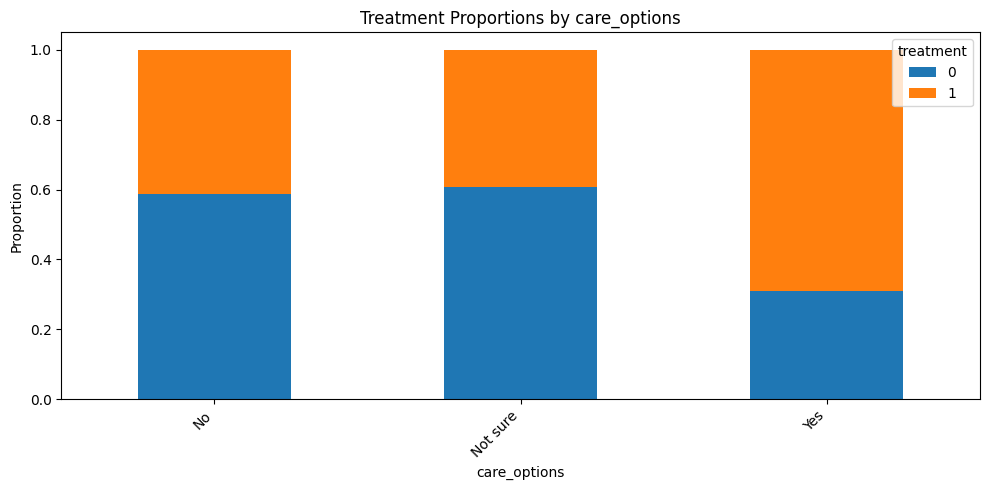

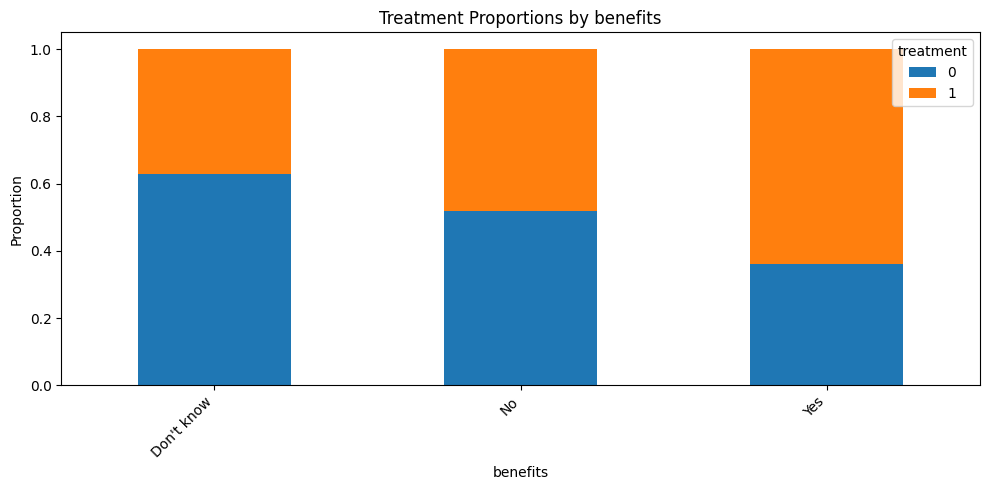

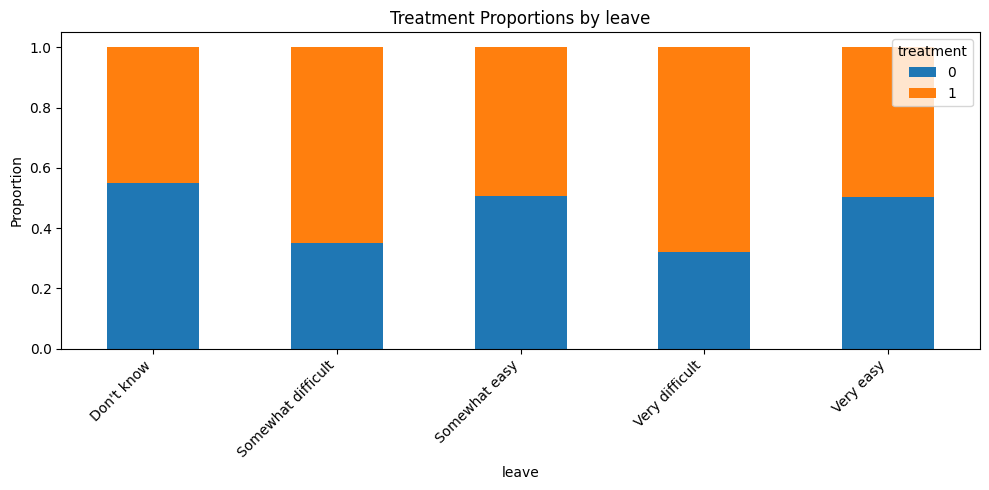

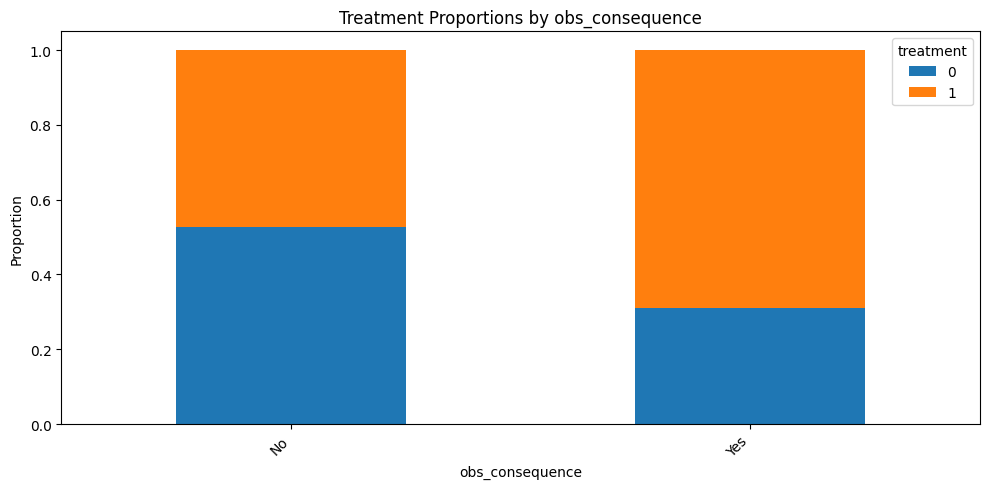

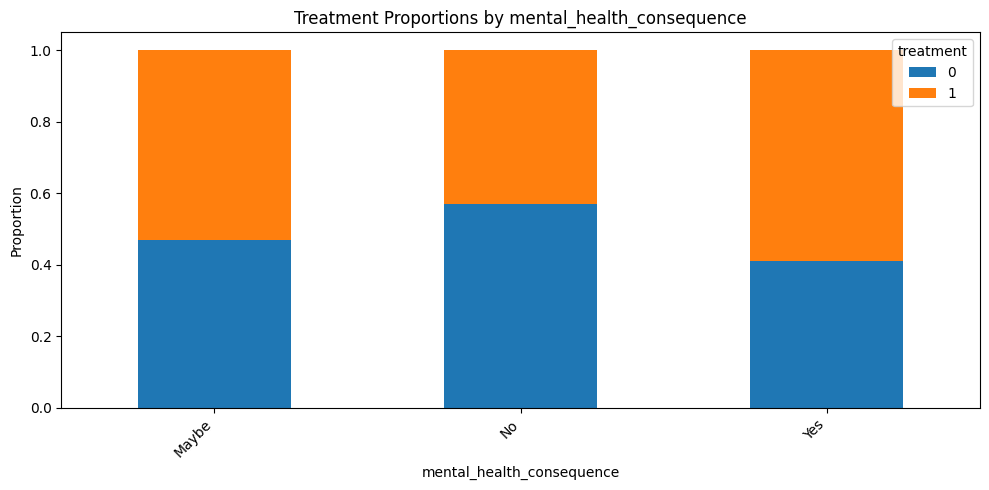

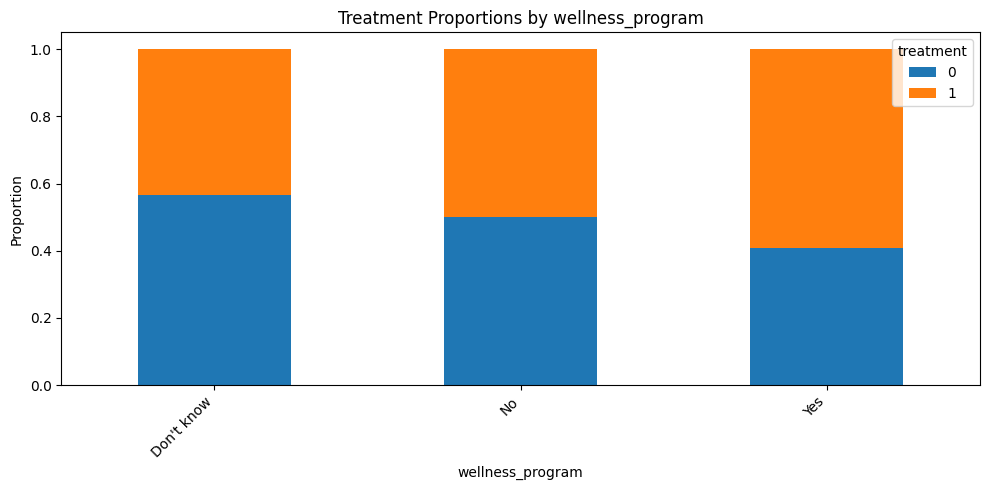

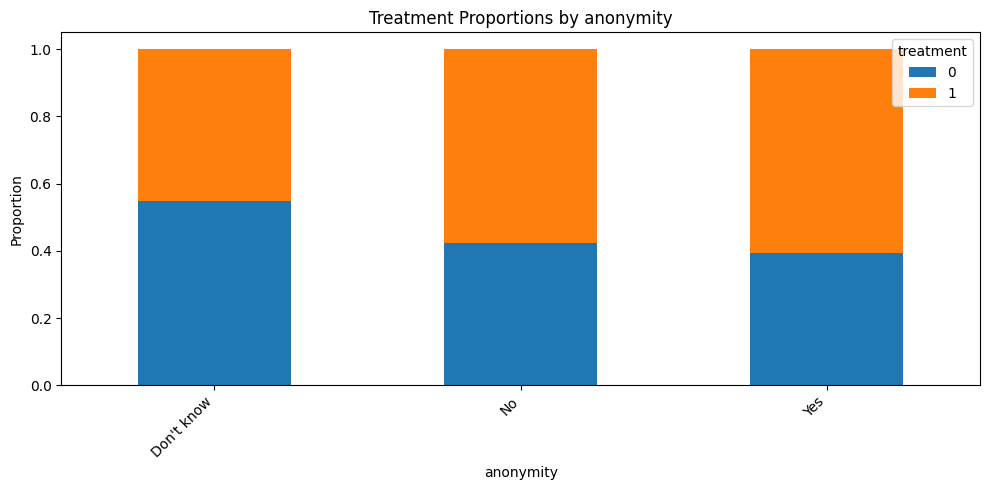

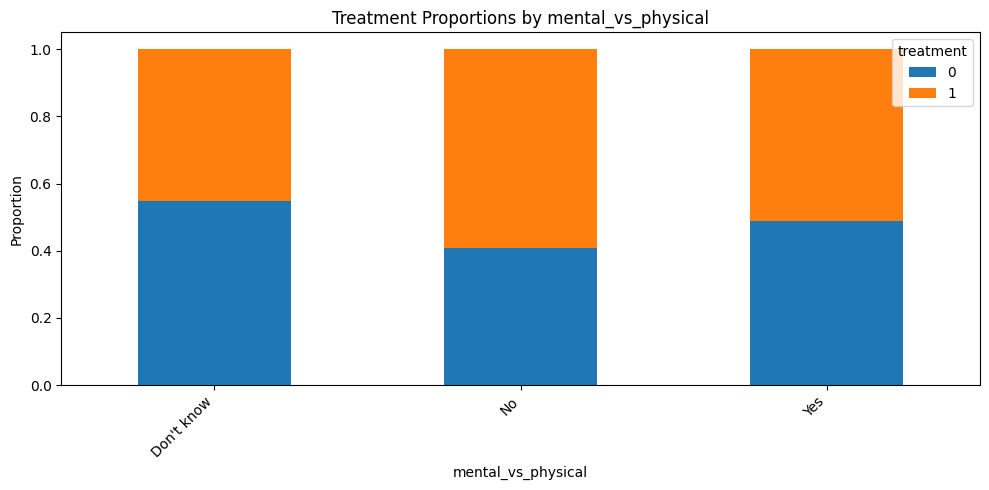

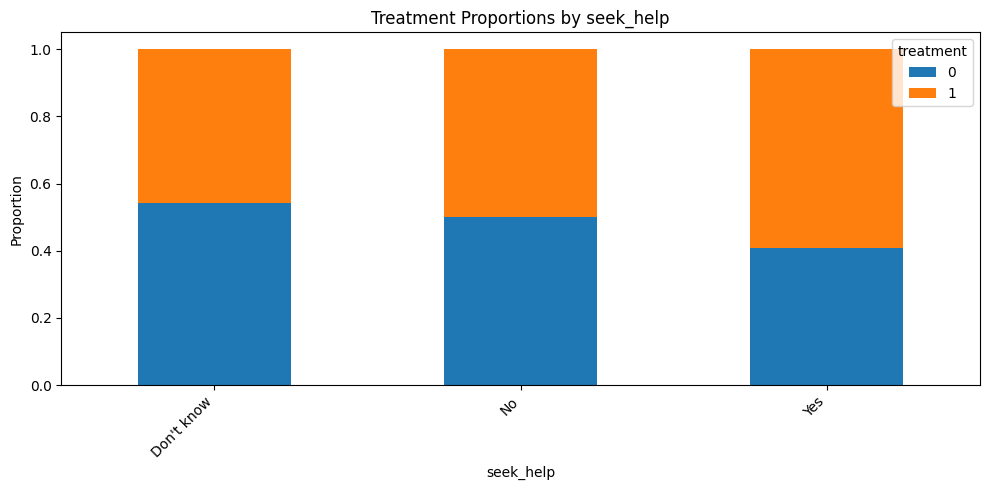

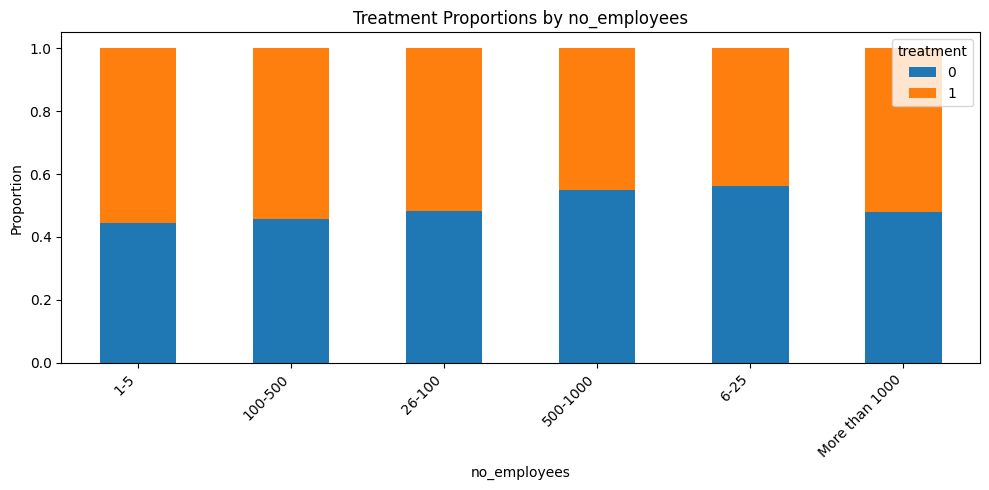

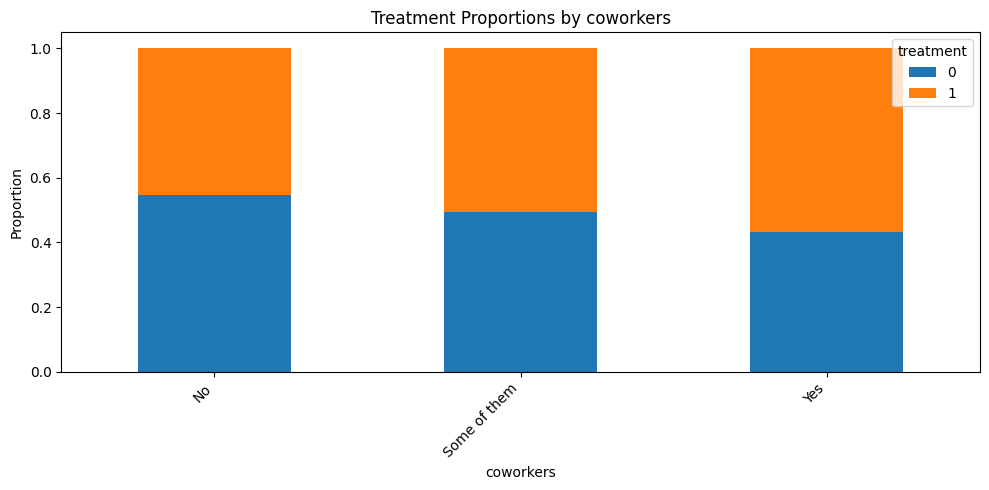

In [86]:
# stacked bar plot for the categorical columns

for col in top_cat_cols:

    prop_df = (
        df.groupby(col)["treatment"]
        .value_counts(normalize=True)
        .unstack()
    )

    prop_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f"Treatment Proportions by {col}")
    plt.ylabel("Proportion")

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

In [87]:
# checking the skewness for logistic regression

df[num_cols].skew().sort_values(ascending=False)

Age    1.012927
dtype: float64

In [88]:
# based on skewness, age is very right skewed in the dataset so it must be handled by dropping outliers 
# or through transformation prior to logistic regression

In [89]:
# final EDA check through SweetViz
from IPython.display import IFrame, display

mental_health_technology = sv.analyze(df)

mental_health_technology.show_html(
    "SWEETVIZ_REPORT.html",
    open_browser=False
)

display(
    IFrame(
        "SWEETVIZ_REPORT.html",
        width="100%",
        height=900
    )
)

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:01 -> (00:00 left)

Report SWEETVIZ_REPORT.html was generated.


# Data Preparation

In [90]:
# Based on EDA, only 3 respondents were non-U.S. citizens, so I dropped country to avoid redundancy between country and state 
df = df.drop(columns=["Country"], errors="ignore")

# I dropped the age outliers - I chose 18 and 85 because you need to be 18 to legally able to work in the U.S. and 80 because there it is 
# over the average retirement age in the U.S., and anything higher than that age is unlikely

In [91]:
# cleaning the binary categorical columns for pipelines
binary_cols = [
    "self_employed",
    "family_history",
    "remote_work",
    "tech_company",
    "benefits",
    "care_options"
]

for col in binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

# Feature Engineering

In [92]:
# Final feature setup after cleaning

# Create support_score
support_cols = ["benefits", "care_options", "wellness_program", "seek_help"]

support_mapping = {
    "yes": 1,
    "no": 0,
    "don't know": 0.5,
    "not sure": 0.5
}

for col in support_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(support_mapping)
    )

df["support_score"] = df[support_cols].mean(axis=1)

In [93]:
# Final modeling setup

df_model = df.drop(
    columns=["Gender_original", "Country"],
    errors="ignore"
)

X = df_model.drop(columns=["treatment"])
y = df_model["treatment"]

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Final X shape:", X.shape)
print("Target distribution:")
display(y.value_counts(normalize=True))

Numeric columns: ['Age', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'state_missing', 'us_based', 'support_score']
Categorical columns: ['state', 'self_employed', 'family_history', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'Gender_cleaned']
Final X shape: (1251, 26)
Target distribution:


treatment
1    0.505196
0    0.494804
Name: proportion, dtype: float64

# Preprocessing pipelines for modeling and handling data


In [94]:

# scaling for age will be handled in numeric_pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])

# Modeling
This section builds and compares several traditional ML models, a Naive Bayes baseline, a neural network, and ensemble models.

In [95]:
X_train, X_val, y_train, y_val = train_test_split(
    X,y, test_size = 0.2, random_state = 42, stratify = y)

In [96]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [97]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

In [98]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
    X_val_processed = X_val_processed.toarray()

nb = GaussianNB()
nb.fit(X_train_processed, y_train)

nb_preds = nb.predict(X_val_processed)

print("Naive Bayes Validation Results")
print("Accuracy:", accuracy_score(y_val, nb_preds))
print("Precision:", precision_score(y_val, nb_preds))
print("Recall:", recall_score(y_val, nb_preds))
print("F1:", f1_score(y_val, nb_preds))
print("\nClassification Report:")
print(classification_report(y_val, nb_preds))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, nb_preds))

Naive Bayes Validation Results
Accuracy: 0.6613545816733067
Precision: 0.6117021276595744
Recall: 0.905511811023622
F1: 0.7301587301587301

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.41      0.55       124
           1       0.61      0.91      0.73       127

    accuracy                           0.66       251
   macro avg       0.71      0.66      0.64       251
weighted avg       0.71      0.66      0.64       251


Confusion Matrix:
[[ 51  73]
 [ 12 115]]


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


model 1: decision tree

In [99]:
dt_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    "model__max_depth": [3, 5, 7, 10, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__criterion": ["gini", "entropy"]
}

dt_grid = GridSearchCV(
    dt_pipe,
    dt_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Decision Tree Params:", dt_grid.best_params_)
print("Best Decision Tree CV F1:", dt_grid.best_score_)

dt_preds = dt_grid.predict(X_val)

print("\nDecision Tree Validation Results")
print(classification_report(y_val, dt_preds))
print(confusion_matrix(y_val, dt_preds))

Best Decision Tree Params: {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 20}
Best Decision Tree CV F1: 0.8424831920336583

Decision Tree Validation Results
              precision    recall  f1-score   support

           0       0.93      0.66      0.77       124
           1       0.74      0.95      0.83       127

    accuracy                           0.81       251
   macro avg       0.84      0.81      0.80       251
weighted avg       0.84      0.81      0.80       251

[[ 82  42]
 [  6 121]]


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Model 2: Random Forest

In [100]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    rf_pipe,
    rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Params:", rf_grid.best_params_)
print("Best Random Forest CV F1:", rf_grid.best_score_)

rf_preds = rf_grid.predict(X_val)

print("\nRandom Forest Validation Results")
print(classification_report(y_val, rf_preds))
print(confusion_matrix(y_val, rf_preds))

Best Random Forest Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 300}
Best Random Forest CV F1: 0.8368961750053397

Random Forest Validation Results
              precision    recall  f1-score   support

           0       0.90      0.71      0.79       124
           1       0.76      0.92      0.84       127

    accuracy                           0.82       251
   macro avg       0.83      0.82      0.81       251
weighted avg       0.83      0.82      0.81       251

[[ 88  36]
 [ 10 117]]


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Model 3: Gradient Boosting

In [101]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=42))
])

gb_params = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    gb_pipe,
    gb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Params:", gb_grid.best_params_)
print("Best Gradient Boosting CV F1:", gb_grid.best_score_)

gb_preds = gb_grid.predict(X_val)

print("\nGradient Boosting Validation Results")
print(classification_report(y_val, gb_preds))
print(confusion_matrix(y_val, gb_preds))

Best Gradient Boosting Params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100}
Best Gradient Boosting CV F1: 0.8531047545171496

Gradient Boosting Validation Results
              precision    recall  f1-score   support

           0       0.87      0.77      0.82       124
           1       0.80      0.89      0.84       127

    accuracy                           0.83       251
   macro avg       0.83      0.83      0.83       251
weighted avg       0.83      0.83      0.83       251

[[ 95  29]
 [ 14 113]]


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Model 4: logistic regression

In [102]:
lr_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

lr_params = {
    "model__C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr_pipe,
    lr_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Logistic Regression Params:", lr_grid.best_params_)
print("Best Logistic Regression CV F1:", lr_grid.best_score_)

lr_preds = lr_grid.predict(X_val)

print("\nLogistic Regression Validation Results")
print(classification_report(y_val, lr_preds))
print(confusion_matrix(y_val, lr_preds))

Best Logistic Regression Params: {'model__C': 1}
Best Logistic Regression CV F1: 0.8384439124657799

Logistic Regression Validation Results
              precision    recall  f1-score   support

           0       0.87      0.78      0.83       124
           1       0.81      0.89      0.85       127

    accuracy                           0.84       251
   macro avg       0.84      0.84      0.84       251
weighted avg       0.84      0.84      0.84       251

[[ 97  27]
 [ 14 113]]


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Model 5: Neural Networks

In [103]:
nn_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(max_iter=1000, random_state=42))
])

nn_params = {
    "model__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.005, 0.01]
}

nn_grid = GridSearchCV(
    nn_pipe,
    nn_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

nn_grid.fit(X_train, y_train)

print("Best Neural Network Params:", nn_grid.best_params_)
print("Best Neural Network CV F1:", nn_grid.best_score_)

nn_preds = nn_grid.predict(X_val)

print("\nNeural Network Validation Results")
print(classification_report(y_val, nn_preds))
print(confusion_matrix(y_val, nn_preds))

Best Neural Network Params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (32,), 'model__learning_rate_init': 0.001}
Best Neural Network CV F1: 0.792894555292769

Neural Network Validation Results
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       124
           1       0.74      0.74      0.74       127

    accuracy                           0.74       251
   macro avg       0.74      0.74      0.74       251
weighted avg       0.74      0.74      0.74       251

[[91 33]
 [33 94]]


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


cross-validation

In [104]:
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_,
    "Neural Network": nn_grid.best_estimator_
}

results = []

# Naive Bayes needs preprocessed dense data
nb_cv_scores = cross_validate(
    GaussianNB(),
    X_train_processed,
    y_train,
    cv=cv,
    scoring=scoring
)

results.append({
    "Model": "Naive Bayes",
    "CV Accuracy": nb_cv_scores["test_accuracy"].mean(),
    "CV Precision": nb_cv_scores["test_precision"].mean(),
    "CV Recall": nb_cv_scores["test_recall"].mean(),
    "CV F1": nb_cv_scores["test_f1"].mean()
})

for name, model in list(models.items())[1:]:
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results).sort_values("CV F1", ascending=False)
display(results_df)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1
3,Gradient Boosting,0.839,0.792229,0.924752,0.853105
1,Decision Tree,0.818,0.749396,0.962376,0.842483
4,Logistic Regression,0.828,0.797552,0.885149,0.838444
2,Random Forest,0.820,0.771511,0.914851,0.836896
5,Neural Network,0.787,0.778746,0.807921,0.792895
0,Naive Bayes,0.709,0.642133,0.960396,0.769518


validation

In [105]:
val_results = []

model_preds = {
    "Naive Bayes": nb_preds,
    "Decision Tree": dt_preds,
    "Random Forest": rf_preds,
    "Gradient Boosting": gb_preds,
    "Logistic Regression": lr_preds,
    "Neural Network": nn_preds
}

for name, preds in model_preds.items():
    val_results.append({
        "Model": name,
        "Validation Accuracy": accuracy_score(y_val, preds),
        "Validation Precision": precision_score(y_val, preds),
        "Validation Recall": recall_score(y_val, preds),
        "Validation F1": f1_score(y_val, preds)
    })

val_results_df = pd.DataFrame(val_results).sort_values("Validation F1", ascending=False)
display(val_results_df)

,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
4,Logistic Regression,0.836653,0.807143,0.889764,0.846442
3,Gradient Boosting,0.828685,0.795775,0.889764,0.840149
2,Random Forest,0.816733,0.764706,0.921260,0.835714
1,Decision Tree,0.808765,0.742331,0.952756,0.834483
5,Neural Network,0.737052,0.740157,0.740157,0.740157
0,Naive Bayes,0.661355,0.611702,0.905512,0.730159


feature importance: Random Forest and Gradient Boosting

,feature,importance
55,cat__work_interfere_Unknown,0.222358
54,cat__work_interfere_Sometimes,0.152880
51,cat__family_history_yes,0.116202
52,cat__work_interfere_Often,0.063674
2,num__care_options,0.049594
0,num__Age,0.035854
7,num__support_score,0.031387
1,num__benefits,0.031161
53,cat__work_interfere_Rarely,0.030848
84,cat__Gender_cleaned_Male,0.019819


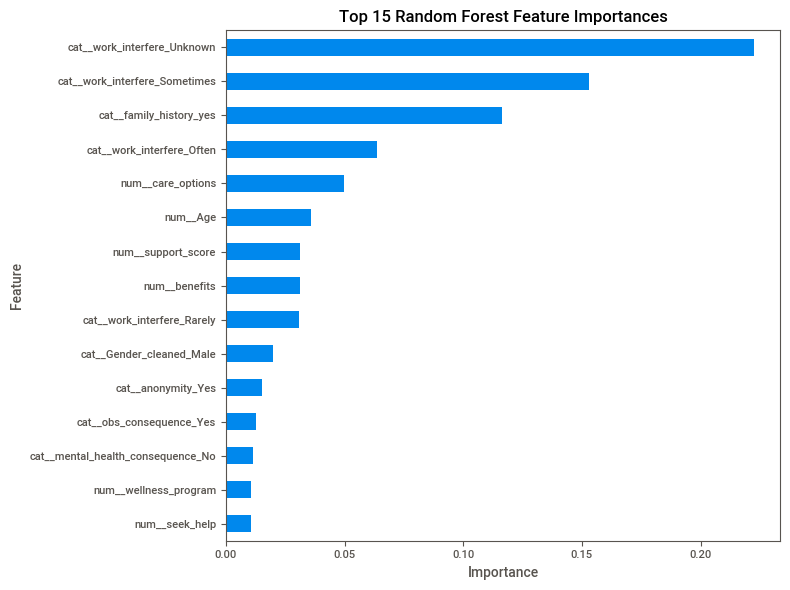

In [106]:
feature_names = rf_grid.best_estimator_.named_steps["preprocessor"].get_feature_names_out()

rf_importances = rf_grid.best_estimator_.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
}).sort_values("importance", ascending=False)

display(rf_importance_df.head(20))

rf_importance_df.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

,feature,importance
55,cat__work_interfere_Unknown,0.389161
54,cat__work_interfere_Sometimes,0.171069
52,cat__work_interfere_Often,0.124503
51,cat__family_history_yes,0.100675
53,cat__work_interfere_Rarely,0.068744
2,num__care_options,0.036694
0,num__Age,0.011674
64,cat__anonymity_Yes,0.010888
1,num__benefits,0.009100
84,cat__Gender_cleaned_Male,0.008619


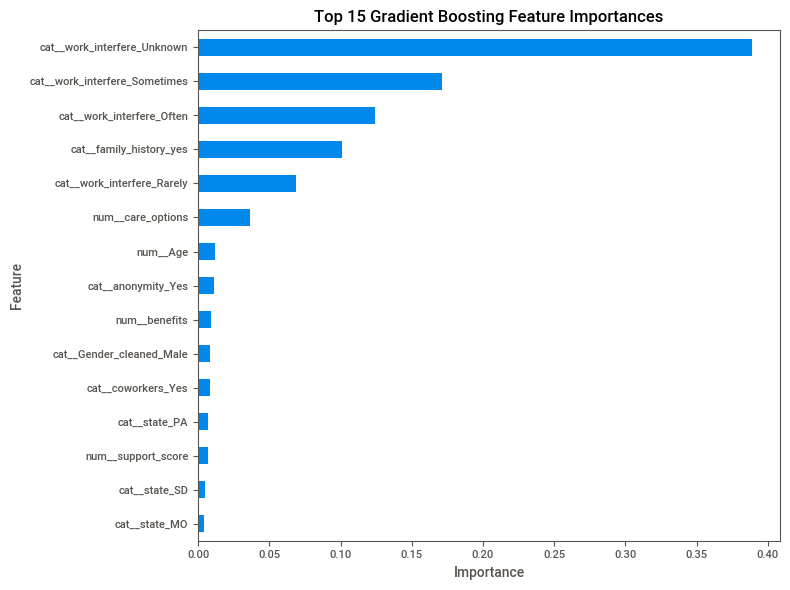

In [107]:
# %%
gb_importances = gb_grid.best_estimator_.named_steps["model"].feature_importances_

gb_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_importances
}).sort_values("importance", ascending=False)

display(gb_importance_df.head(20))

gb_importance_df.head(15).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Top 15 Gradient Boosting Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

logreg coefficients

,feature,coefficient,absolute_coefficient
52,cat__work_interfere_Often,2.885296,2.885296
54,cat__work_interfere_Sometimes,2.485221,2.485221
55,cat__work_interfere_Unknown,-2.195992,2.195992
53,cat__work_interfere_Rarely,2.047125,2.047125
22,cat__state_MD,-1.110618,1.110618
32,cat__state_NV,1.047614,1.047614
8,cat__state_AZ,1.030274,1.030274
51,cat__family_history_yes,0.968068,0.968068
37,cat__state_PA,-0.950307,0.950307
74,cat__coworkers_Yes,0.906572,0.906572


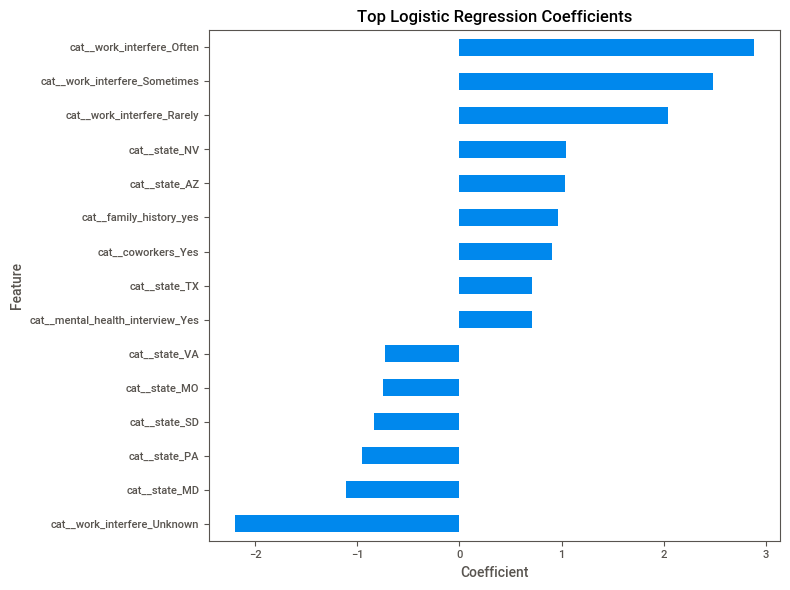

In [108]:
# %% [markdown]
# ## Logistic Regression Coefficients
#
# Logistic Regression coefficients help interpret which encoded features are associated with higher or lower probability of seeking treatment.

# %%
lr_feature_names = lr_grid.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
lr_coefs = lr_grid.best_estimator_.named_steps["model"].coef_[0]

lr_coef_df = pd.DataFrame({
    "feature": lr_feature_names,
    "coefficient": lr_coefs,
    "absolute_coefficient": np.abs(lr_coefs)
}).sort_values("absolute_coefficient", ascending=False)

display(lr_coef_df.head(20))

lr_coef_df.head(15).sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

ensemble 1: soft voting

In [109]:
soft_voting = VotingClassifier(
    estimators=[
        ("lr", lr_grid.best_estimator_),
        ("rf", rf_grid.best_estimator_),
        ("gb", gb_grid.best_estimator_)
    ],
    voting="soft"
)

soft_voting.fit(X_train, y_train)

soft_preds = soft_voting.predict(X_val)

print("Soft Voting Ensemble Validation Results")
print(classification_report(y_val, soft_preds))
print(confusion_matrix(y_val, soft_preds))

soft_scores = cross_validate(
    soft_voting,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

soft_result = {
    "Model": "Soft Voting Ensemble",
    "CV Accuracy": soft_scores["test_accuracy"].mean(),
    "CV Precision": soft_scores["test_precision"].mean(),
    "CV Recall": soft_scores["test_recall"].mean(),
    "CV F1": soft_scores["test_f1"].mean()
}

soft_result

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Soft Voting Ensemble Validation Results
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       124
           1       0.80      0.90      0.84       127

    accuracy                           0.83       251
   macro avg       0.84      0.83      0.83       251
weighted avg       0.84      0.83      0.83       251

[[ 95  29]
 [ 13 114]]


{'Model': 'Soft Voting Ensemble',
 'CV Accuracy': np.float64(0.829),
 'CV Precision': np.float64(0.7842233738247796),
 'CV Recall': np.float64(0.9128712871287128),
 'CV F1': np.float64(0.8434769579840848)}

ensemble 2: stacking

In [110]:
stacking = StackingClassifier(
    estimators=[
        ("dt", dt_grid.best_estimator_),
        ("rf", rf_grid.best_estimator_),
        ("gb", gb_grid.best_estimator_)
    ],
    final_estimator=LogisticRegression(max_iter=3000),
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)

stack_preds = stacking.predict(X_val)

print("Stacking Ensemble Validation Results")
print(classification_report(y_val, stack_preds))
print(confusion_matrix(y_val, stack_preds))

stack_scores = cross_validate(
    stacking,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

stack_result = {
    "Model": "Stacking Ensemble",
    "CV Accuracy": stack_scores["test_accuracy"].mean(),
    "CV Precision": stack_scores["test_precision"].mean(),
    "CV Recall": stack_scores["test_recall"].mean(),
    "CV F1": stack_scores["test_f1"].mean()
}

stack_result

c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Stacking Ensemble Validation Results
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       124
           1       0.79      0.90      0.84       127

    accuracy                           0.82       251
   macro avg       0.83      0.82      0.82       251
weighted avg       0.83      0.82      0.82       251

[[ 93  31]
 [ 13 114]]


{'Model': 'Stacking Ensemble',
 'CV Accuracy': np.float64(0.836),
 'CV Precision': np.float64(0.789994618527797),
 'CV Recall': np.float64(0.9207920792079207),
 'CV F1': np.float64(0.8501581799031467)}

In [ ]:
final model comparison

In [111]:
ensemble_results_df = pd.DataFrame([soft_result, stack_result])

final_cv_results = pd.concat(
    [results_df, ensemble_results_df],
    ignore_index=True
).sort_values("CV F1", ascending=False)

display(final_cv_results)

ensemble_val_results = pd.DataFrame([
    {
        "Model": "Soft Voting Ensemble",
        "Validation Accuracy": accuracy_score(y_val, soft_preds),
        "Validation Precision": precision_score(y_val, soft_preds),
        "Validation Recall": recall_score(y_val, soft_preds),
        "Validation F1": f1_score(y_val, soft_preds)
    },
    {
        "Model": "Stacking Ensemble",
        "Validation Accuracy": accuracy_score(y_val, stack_preds),
        "Validation Precision": precision_score(y_val, stack_preds),
        "Validation Recall": recall_score(y_val, stack_preds),
        "Validation F1": f1_score(y_val, stack_preds)
    }
])

final_val_results = pd.concat(
    [val_results_df, ensemble_val_results],
    ignore_index=True
).sort_values("Validation F1", ascending=False)

display(final_val_results)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1
0,Gradient Boosting,0.839,0.792229,0.924752,0.853105
7,Stacking Ensemble,0.836,0.789995,0.920792,0.850158
6,Soft Voting Ensemble,0.829,0.784223,0.912871,0.843477
1,Decision Tree,0.818,0.749396,0.962376,0.842483
2,Logistic Regression,0.828,0.797552,0.885149,0.838444
3,Random Forest,0.820,0.771511,0.914851,0.836896
4,Neural Network,0.787,0.778746,0.807921,0.792895
5,Naive Bayes,0.709,0.642133,0.960396,0.769518


,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
0,Logistic Regression,0.836653,0.807143,0.889764,0.846442
6,Soft Voting Ensemble,0.832669,0.797203,0.897638,0.844444
1,Gradient Boosting,0.828685,0.795775,0.889764,0.840149
7,Stacking Ensemble,0.824701,0.786207,0.897638,0.838235
2,Random Forest,0.816733,0.764706,0.921260,0.835714
3,Decision Tree,0.808765,0.742331,0.952756,0.834483
4,Neural Network,0.737052,0.740157,0.740157,0.740157
5,Naive Bayes,0.661355,0.611702,0.905512,0.730159


final model selection

In [112]:
best_model_name = final_val_results.iloc[0]["Model"]
print("Best model based on validation F1:", best_model_name)

model_lookup = {
    "Naive Bayes": nb,
    "Decision Tree": dt_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "Logistic Regression": lr_grid.best_estimator_,
    "Neural Network": nn_grid.best_estimator_,
    "Soft Voting Ensemble": soft_voting,
    "Stacking Ensemble": stacking
}

final_model = model_lookup[best_model_name]

Best model based on validation F1: Logistic Regression


In [113]:
if best_model_name == "Naive Bayes":
    final_preds = nb.predict(X_val_processed)
else:
    final_preds = final_model.predict(X_val)

print("Final Model:", best_model_name)
print(classification_report(y_val, final_preds))
print(confusion_matrix(y_val, final_preds))

Final Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.78      0.83       124
           1       0.81      0.89      0.85       127

    accuracy                           0.84       251
   macro avg       0.84      0.84      0.84       251
weighted avg       0.84      0.84      0.84       251

[[ 97  27]
 [ 14 113]]


c:\Users\ivpri\gsb545\.venv_clean\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [114]:
summary_table = final_val_results.copy()

summary_table["Model Type"] = summary_table["Model"].map({
    "Naive Bayes": "Probabilistic baseline",
    "Decision Tree": "Single tree",
    "Random Forest": "Bagging ensemble",
    "Gradient Boosting": "Boosting ensemble",
    "Logistic Regression": "Linear interpretable baseline",
    "Neural Network": "Nonlinear neural network",
    "Soft Voting Ensemble": "Probability averaging ensemble",
    "Stacking Ensemble": "Meta-model ensemble"
})

summary_table = summary_table[
    [
        "Model",
        "Model Type",
        "Validation Accuracy",
        "Validation Precision",
        "Validation Recall",
        "Validation F1"
    ]
]

display(summary_table)

,Model,Model Type,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
0,Logistic Regression,Linear interpretable baseline,0.836653,0.807143,0.889764,0.846442
6,Soft Voting Ensemble,Probability averaging ensemble,0.832669,0.797203,0.897638,0.844444
1,Gradient Boosting,Boosting ensemble,0.828685,0.795775,0.889764,0.840149
7,Stacking Ensemble,Meta-model ensemble,0.824701,0.786207,0.897638,0.838235
2,Random Forest,Bagging ensemble,0.816733,0.764706,0.921260,0.835714
3,Decision Tree,Single tree,0.808765,0.742331,0.952756,0.834483
4,Neural Network,Nonlinear neural network,0.737052,0.740157,0.740157,0.740157
5,Naive Bayes,Probabilistic baseline,0.661355,0.611702,0.905512,0.730159
